In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    StratifiedShuffleSplit
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor
)

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [39]:
df = pd.read_excel("dataset_SO2_completo.xlsx")

In [40]:
X_cols = [
    "weight_urbanization_20.0km",
    "distance_to_industry_20.0km",
    "weigthed_industry_20.0km",
    "edgar_so2_emission",
    "merra2_so2mass",
    "hdr_co2_prod",
    "hdr_hdi",
    "era5_relative_humidity",
    "era5_temperature",
    "roughness_mean"
]

y_col = "so2"

## Estratificação de poluição (ISO 9223)

As concentrações de dióxido de enxofre são estratificadas conforme a classificação de poluição da norma ISO 9223. Ou seja, para valores abaixo ou igual a 4mg/m^2d, são classificados como P0; se menor ou igual a 24mg/m^2d são p1; se menor ou igual a 80mg/m^2d são p2; caso contrário, os valores são considerados p3 (com valores máximos de 200mg/m^2d).

In [41]:
def stratify_so2(x):

    if x <= 4:
        return "p0"

    elif x <= 24:
        return "p1"

    elif x <= 80:
        return "p2"

    else:
        return "p3"

df["pollution_class"] = df["so2"].apply(stratify_so2)

In [42]:
df_train = df[
    df["project_name"] != "africa_saaqis_2025"
].copy()

df_test = df[
    df["project_name"] == "africa_saaqis_2025"
].copy()

In [43]:
X_train = df_train[X_cols]
y_train = df_train[y_col]

X_test = df_test[X_cols]
y_test = df_test[y_col]

stratify_train = df_train["pollution_class"]

## Modelos Considerados

Aqui, consideramos Random Forest (RF), ET (ExtraTrees) ou SVR (Suport Vector Regressor)

In [44]:
rf = RandomForestRegressor(
    n_estimators=400,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=20,
    bootstrap=False,
    random_state=42
)

et = ExtraTreesRegressor(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=1.0,
    max_depth=20,
    bootstrap=False,
    random_state=42
)

svr = Pipeline([
    (
        "scaler",
        MinMaxScaler()
    ),
    (
        "svr",
        SVR(
            kernel="rbf",
            C=100,
            gamma="scale",
            epsilon=0.5
        )
    )
])

# nn = Pipeline([
#     (
#         "scaler",
#         MinMaxScaler()
#     ),
#     (
#         "mlp",
#         MLPRegressor(
#             hidden_layer_sizes=(128,128),
#             activation='relu',
#             solver='adam',
#             batch_size=16,
#             learning_rate='adaptive',
#             max_iter=200,
#             early_stopping=True,
#             validation_fraction=0.1,
#             n_iter_no_change=50,
#             random_state=42
#         )
#     )
# ])

In [45]:
models = {
    "RF": rf,
    "ET": et,
    "SVR": svr,
    # "NN": nn
}

## Validação 
Estamos usando o Random Subsampling Estratificado (ou Monte Carlo Cross-Validation Estratificado). Ou seja, são criadas várias divisões aleatórias de treino e validação, mantendo a proporção das classes de estratificação. Em cada repetição, 70% dos dados são divididos para treino e 30% para validação (train_size = 0.7), e o processo é repetido 100 vezes (n_splits=100). 

A cada repetição acontece:
- os índices são embaralhados;
- é criado um novo conjunto de treino e validação;
- o modelo é treinado novamente;
- as métricas (R^2, RMSE e MAE) são calculadas.

No final, é obtido uma distribuição de desempenho em vez de um único valor de R^2.

In [46]:
cv = StratifiedShuffleSplit(
    n_splits=100,
    train_size=0.7,
    random_state=42
)

In [47]:
def evaluate_model(
        model,
        X,
        y,
        stratify
):

    results = []

    for train_idx, val_idx in cv.split(
            X,
            stratify
    ):

        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model.fit(
            X_tr,
            y_tr
        )

        pred = model.predict(
            X_val
        )

        results.append({
            "R2":
                r2_score(
                    y_val,
                    pred
                ),

            "MAE":
                mean_absolute_error(
                    y_val,
                    pred
                ),

            "RMSE":
                np.sqrt(
                    mean_squared_error(
                        y_val,
                        pred
                    )
                )
        })

    return pd.DataFrame(results)

In [49]:
validation_results = {}

for name, model in models.items():

    validation_results[name] = evaluate_model(
        model,
        X_train,
        y_train,
        stratify_train
    )

In [50]:
summary_validation = pd.DataFrame({
    name: df_.mean()
    for name, df_ in validation_results.items()
}).T

summary_validation

,R2,MAE,RMSE
RF,0.776663,2.622203,4.469522
ET,0.784336,2.597504,4.391050
SVR,0.681855,3.377644,5.327832


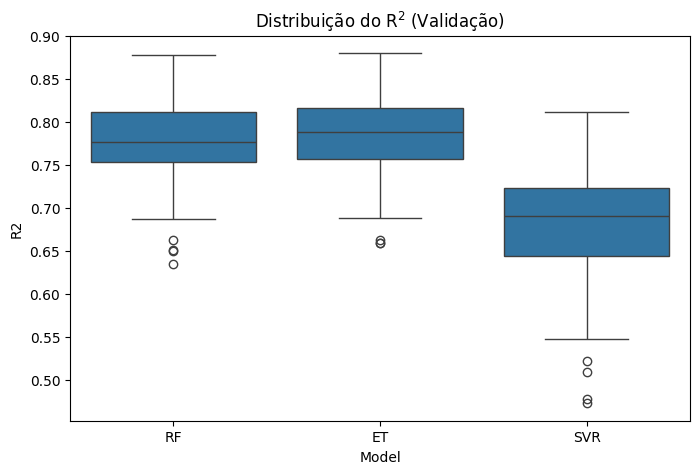

In [51]:
all_results = []

for name, df_result in validation_results.items():

    temp = df_result.copy()

    temp["Model"] = name

    all_results.append(temp)

results = pd.concat(
    all_results,
    ignore_index=True
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=results,
    x="Model",
    y="R2"
)

plt.title(
    "Distribuição do R$^2$ (Validação)"
)

plt.show()

## Teste



In [52]:
test_results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    test_results.append({
        "Model": name,

        "R2":
            r2_score(
                y_test,
                pred
            ),

        "MAE":
            mean_absolute_error(
                y_test,
                pred
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    y_test,
                    pred
                )
            )
    })

In [53]:
summary_test = pd.DataFrame(
    test_results
)

summary_test

,Model,R2,MAE,RMSE
0,RF,0.049436,6.836384,8.344619
1,ET,0.067937,6.633692,8.263012
2,SVR,-0.064953,6.392522,8.832444


## Comparação entre Validação e Teste

In [54]:
comparison = (
    summary_validation
    .reset_index()
    .rename(
        columns={"index":"Model"}
    )
    .merge(
        summary_test,
        on="Model",
        suffixes=(
            "_Validation",
            "_Test"
        )
    )
)

comparison

,Model,R2_Validation,MAE_Validation,RMSE_Validation,R2_Test,MAE_Test,RMSE_Test
0,RF,0.776663,2.622203,4.469522,0.049436,6.836384,8.344619
1,ET,0.784336,2.597504,4.391050,0.067937,6.633692,8.263012
2,SVR,0.681855,3.377644,5.327832,-0.064953,6.392522,8.832444


## Treinamento final

In [55]:
best_model = models["ET"]

X_full = df[X_cols]
y_full = df[y_col]

best_model.fit(
    X_full,
    y_full
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induc

In [ ]:
joblib.dump(
    best_model,
    "modelo_so2.pkl"
)